# Geneset enrichment analysis of scRNA-seq kpcTN data

In [ ]:
"""Load the Adata file """

import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import scanpy as sc
from pylab import *
import numpy as np
import gseapy as gp
from gseapy import barplot, dotplot, heatmap
from gseapy.plot import gseaplot
from matplotlib.patches import Patch
import sys
import matplotlib


# Load data

In [2]:
writeDir='/...'
OutDir = '/...'
cellType = 'Fibroblast'

# sc.read_csv(filename)
# load meta file
cells_keep=adata.obs_names[adata.obs['Fibroblasts'].isin(['iCAF','myCAF','apCAF','0'])]
adata = adata[cells_keep,:]
adata.uns['log1p']['base'] = None
clust_sel = 'Fibroblasts'

# Generate the DGE Table

In [3]:
""" Creating a list to control the order of clusters """

grouplist =  ['iCAF','myCAF','apCAF','0']

""" Computing calculations """

# Calculating mean expression & pct expression
gene_ids = adata.raw.var.index.values
cluster = adata.obs[clust_sel].cat.categories
    
obs = adata.raw[:, gene_ids].X.toarray()
obs = pd.DataFrame(obs, columns = gene_ids, index=adata.obs[clust_sel])
average_obs = obs.groupby(level=0).mean()
obs_bool = obs.astype(bool)
fraction_obs = obs_bool.groupby(level=0).sum()/obs_bool.groupby(level=0).count()*100
    
mean_expr = average_obs.T
fraction = fraction_obs.T

df = pd.DataFrame()


# lfc , mean-exp & pct-exp

""" zipping list together to get only pairing I care about 1:1 """
for i in grouplist:
    sc.tl.rank_genes_groups(adata, clust_sel, groups=[i],  method='t-test', reference='rest',
                            use_raw=True, key_added= i)
    
    result = adata.uns[i]
    
    #Create a dictionary with the lfc results and append column to table
    colname = 'lfc'
    lfc_dict = dict()
    for k in result['names'].dtype.names:
        lfc_dict[k] = dict(zip(result['names'][k], result['logfoldchanges'][k]))
    test = pd.DataFrame(lfc_dict)
            
    test.columns = [colname]
    df = pd.concat([df, test], axis=1)
            
    # Create a dictionary for the adjusted p-values and append column to table
    colname1 = 'Apval'
    Apval_dict = dict()
    for m in result['names'].dtype.names:
        Apval_dict[m] = dict(zip(result['names'][m], result['pvals_adj'][m]))
    test2 = pd.DataFrame(Apval_dict)
            
    test2.columns = [colname1]
    df = pd.concat([df, test2], axis=1)

    # Create a dictionary for the p-values and append column to table
    colname2 = 'score'
    score_dict = dict()
    for o in result['names'].dtype.names:
        score_dict[o] = dict(zip(result['names'][o], result['scores'][o]))
    test3 = pd.DataFrame(score_dict)
            
    test3.columns = [colname2]
    df = pd.concat([df, test3], axis=1)
    
    # Appending mean-exp to table for i
    colname3 = i + '_mean-exp'
    test4 = mean_expr[[i]]
    test4.columns = [colname3]
    df = pd.concat([df, test4], axis=1)
    
    # Appending pct-exp to table for i
    colname4 = i + '_pct-exp'
    test5 = fraction[[i]]
    test5.columns = [colname4]
    df = pd.concat([df, test5], axis=1)
    
# Convert to human genes
df.index = df.index.map(str.upper)

/home/hinds/anaconda3/envs/gsea/lib/python3.10/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


# Step 2

In [5]:
libs = ['Reactome_2022','GO_Biological_Process_2023','GO_Molecular_Function_2023',
        'GO_Cellular_Component_2023']

srtlst = []

for u in libs:
    go_mf = gp.get_library(name=u)
    
    # Iterate through each key in the dictionary
    for key in go_mf.keys():
        # Check if the key contains 'Axon' or 'axon'
        if 'Axon' in key or 'axon' in key:
            # Add the key to the list
            srtlst.append(key)

2025-11-14 19:17:03,762 [WARNING] Duplicated values found in preranked stats: 5.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:17:03,763 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:17:03,764 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:17:03,779 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:17:03,806 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:17:03,819 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:17:03,880 [INFO] 0819 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:17:03,881 [INFO] 8027 gene_sets used for further statistical testing.....
2025-11-14 19:17:03,881 [INFO] Start to run GSEA...Might t

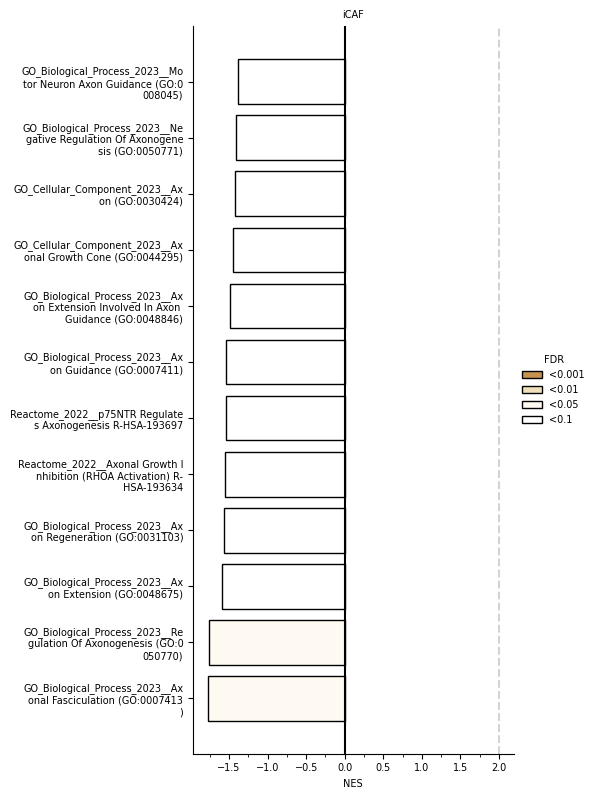

2025-11-14 19:19:05,668 [WARNING] Duplicated values found in preranked stats: 5.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:19:05,668 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:19:05,668 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:19:05,685 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:19:05,711 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:19:05,724 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:19:05,781 [INFO] 0819 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:19:05,782 [INFO] 8027 gene_sets used for further statistical testing.....
2025-11-14 19:19:05,782 [INFO] Start to run GSEA...Might t

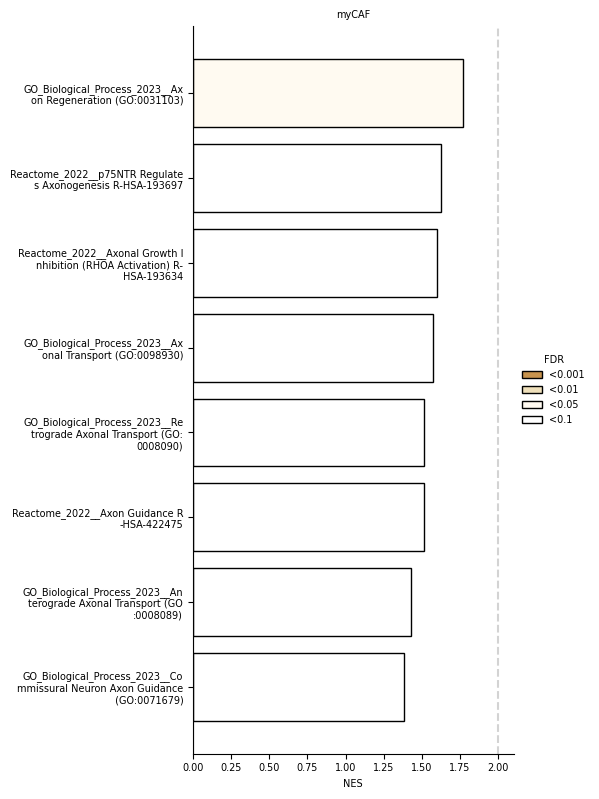

2025-11-14 19:21:08,503 [WARNING] Duplicated values found in preranked stats: 5.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:21:08,504 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:21:08,505 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:21:08,520 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:21:08,548 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:21:08,554 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:21:08,642 [INFO] 0819 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:21:08,643 [INFO] 8027 gene_sets used for further statistical testing.....
2025-11-14 19:21:08,644 [INFO] Start to run GSEA...Might t

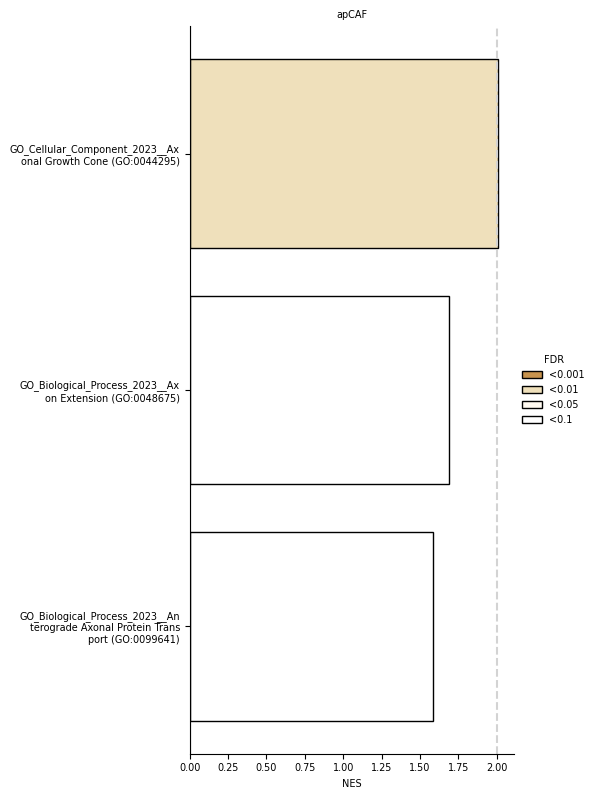

2025-11-14 19:23:09,579 [WARNING] Duplicated values found in preranked stats: 5.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:23:09,580 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:23:09,580 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:23:09,596 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:23:09,624 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:23:09,631 [INFO] Enrichr library gene sets already downloaded in: /home/hinds/.cache/gseapy, use local file
2025-11-14 19:23:09,704 [INFO] 0819 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:23:09,705 [INFO] 8027 gene_sets used for further statistical testing.....
2025-11-14 19:23:09,705 [INFO] Start to run GSEA...Might t

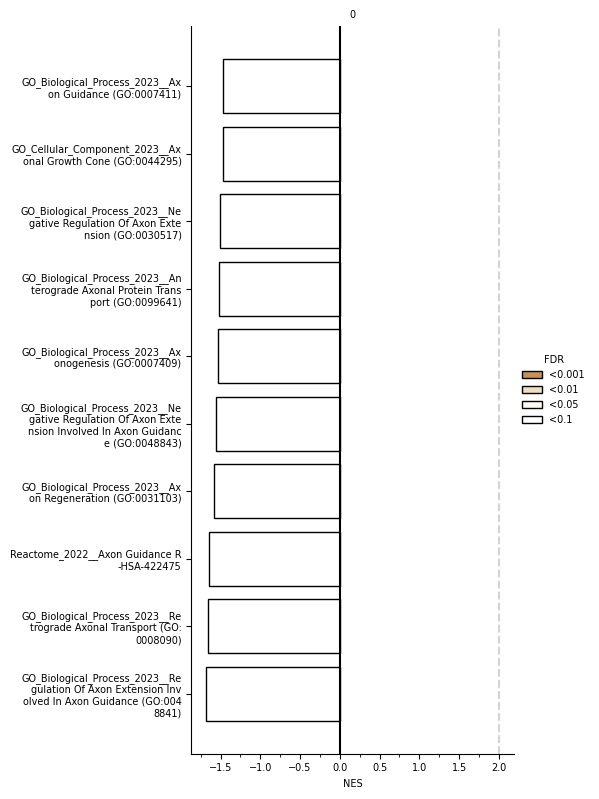

In [6]:
with pd.ExcelWriter(OutDir + 'GSEA' + '_kpcTN_Results' + '.xlsx') as xlswriter:
    k = -5
    for a in grouplist:
        k = k + 5
        sect = df.iloc[:,k:k+5]
    
        # Add ensemble gene info
        sect['ID'] = adata.var.id

        sect.sort_values(by=['score'], ascending=False, inplace=True)
    
        ranking = sect[['score']]
        ranking.reset_index(inplace=True)
    
        pre_res = gp.prerank(rnk = ranking, 
                             gene_sets= libs,
                             threads=4,
                             min_size=5,
                             max_size=1000,
                             permutation_num=1000, # reduce number to speed up testing
                             outdir=None, # don't write to disk
                             seed=6,
                             verbose=True, # see what's going on behind the scenes
                            )
    
        # generate a dataframe from gsea output
        table = pre_res.res2d
        
        #Keep only cetain pathways
        filtered_table = table[table['Term'].str.contains('Axon|axon', case=False)]
        
        filtered_table.to_excel(xlswriter, index=True, sheet_name = a)
        
        ## Sort the report by 'NES' column in descending order
        filtered_table = filtered_table.sort_values(by='NES', ascending=False)
    
        tab = filtered_table[(filtered_table['FDR q-val'] < 0.3)]
        tab1 = tab[(tab['NES'] > 1.0) | (tab['NES'] < -1.0) ]
        #tab1['Term'] = tab1['Term'].str.replace('GO_Molecular_Function_2023__','',regex=True)
    
        # Select only the first 5 and last 3 pathways in dataframe
    
        first_set = tab1.iloc[:15]
        #last_set = tab1.iloc[-4:]
    
        df_sorted = first_set
        #df_sorted = pd.concat([first_set,last_set])
        df_sorted = df_sorted.sort_values(by='NES', ascending=True)
                         
        # Creating the figure and axes
        plt.rcParams['font.size'] = 7
        fig, ax = plt.subplots(figsize=(6,8))
        ax.xaxis.set_minor_locator(MultipleLocator(0.25))  # Set minor ticks every 0.25 units

        # Plotting the horizontal barplot
        for x, row in df_sorted.iterrows():
            if row['FDR q-val'] < 0.001:
                color = '#c7934e'
            elif row['FDR q-val'] < 0.005:
                color = '#efe0bb'
            elif row['FDR q-val'] < 0.05:
                color = '#fffaf1'
            else:
                color = '#FFFFFF'

            # Splitting label into lines with 50 characters each
            term = row['Term']
            term_lines = [term[i:i+30] for i in range(0, len(term), 30)]
            term = '\n'.join(term_lines)

            ax.barh(str(term), float(row['NES']), color=color, edgecolor='black')  # Corrected here

        # Adding x=0 line
        ax.axvline(x=0, linestyle='-', color='black')
        ax.axvline(x=2, linestyle='--', color='lightgray')  # Dashed line at x=1
        #ax.axvline(x=-2, linestyle='--', color='lightgray')  # Dashed line at x=1

        # Removing top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Rotate y-axis labels and set font size
        plt.yticks(rotation=0, fontsize=7)
        plt.xticks(rotation=0, fontsize=7)

        # Creating custom legend
        legend_elements = [
            Patch(facecolor='#c7934e', edgecolor='black', label='<0.001'),
            Patch(facecolor='#efe0bb', edgecolor='black', label='<0.01'),
            Patch(facecolor='#fffaf1', edgecolor='black', label='<0.05'),
            Patch(facecolor='#FFFFFF', edgecolor='black', label='<0.1')
        ]

        ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="FDR", frameon=False,fontsize=7)
        ax.set_xlabel('NES', fontsize=7)  
        ax.set_title(a, fontsize=7) 
        ax.grid(False)

        # Adjust layout to accommodate longer labels
        plt.tight_layout()

        # Displaying the plot
        plt.show()
        

**Custom Genesets**

In [7]:
axon_pathways_gene_sets = {'Multimodal Axon Guidance and Neurotrophic Signaling': [
    'AGRN', 'ARTN', 'BDNF', 'COL3A1', 'COL4A1', 'COL4A2', 'COL4A3', 'COL4A4', 'COL5A1', 'COL5A2', 'COL5A3', 'COL6A1', 
    'COL6A2', 'COL6A3', 'COL6A5', 'COL6A6', 'COL9A1', 'COL9A2', 'COL9A3', 'CXCL12', 'DRAXIN', 'EFNA1', 'EFNA2', 'EFNA3', 
    'EFNA4', 'EFNA5', 'EFNB1', 'EFNB2', 'EFNB3', 'FN1', 'GDNF', 'GFRA1', 'GFRA2', 'GFRA3', 'GFRA4', 'GPC1', 'L1CAM', 
    'LAMA1', 'LAMB1', 'LAMC1', 'MMP2', 'MMP9', 'NCAM1', 'NEO1', 'NGF', 'NRCAM', 'NREP', 'NRTN', 'NTF3', 'NTN1', 
    'NTN4', 'NRP1', 'NRP2', 'PLXNA1', 'PLXNA2', 'PLXNA3', 'PLXNA4', 'PLXNB1', 'PLXNB2', 'PLXNB3', 'PLXNB4', 'PLXNC1', 
    'PLXND1', 'PLEXNB3', 'PSPN', 'RGMA', 'ROBO1', 'ROBO2', 'ROBO3', 'ROBO4', 'SEMA3A', 'SEMA3E', 'SEMA3F', 'SEMA4A', 
    'SEMA4D', 'SEMA5A', 'SEMA6A', 'SEMA6D', 'SEMA7A', 'SLIT1', 'SLIT2', 'SLIT3', 'TGFB1', 'TNC', 'EPHA1', 'EPHA3', 
    'EPHA4', 'EPHA5', 'EPHA10', 'EPHB1', 'EPHB2', 'EPHB4', 'UNC5A', 'UNC5C', 'UNC5D'
]}

In [8]:
axon_pathways_gene_sets = {'Multimodal Axon Guidance and Neurotrophic Signaling': [
    'Agrn', 'Artn', 'Bdnf', 'Col3a1', 'Col4a1', 'Col4a2', 'Col4a3', 'Col4a4', 'Col5a1', 'Col5a2', 'Col5a3', 'Col6a1', 
    'Col6a2', 'Col6a3', 'Col6a5', 'Col6a6', 'Col9a1', 'Col9a2', 'Col9a3', 'Cxcl12', 'Draxin', 'Efna1', 'Efna2', 'Efna3', 
    'Efna4', 'Efna5', 'EfnB1', 'EfnB2', 'EfnB3', 'Fn1', 'Gdnf', 'Gfra1', 'Gfra2', 'Gfra3', 'Gfra4', 'Gpc1', 'L1cam', 
    'Lama1', 'Lamb1', 'Lamc1', 'Mmp2', 'Mmp9', 'Ncam1', 'Neo1', 'Ngf', 'Nrcam', 'Nrep', 'NrtN', 'Ntf3', 'Ntn1', 
    'Ntn4', 'NrP1', 'NrP2', 'Plxna1', 'Plxna2', 'Plxna3', 'Plxna4', 'Plxnb1', 'Plxnb2', 'Plxnb3', 'Plxnb4', 'PlxnC1', 
    'Plxnd1', 'Plexnb3', 'Pspn', 'Rgma', 'Robo1', 'Robo2', 'Robo3', 'Robo4', 'Sema3a', 'Sema3e', 'Sema3f', 'Sema4a', 
    'Sema4d', 'Sema5a', 'Sema6a', 'Sema6d', 'Sema7a', 'Slit1', 'Slit2', 'Slit3', 'Tgfb1', 'Tnc', 'Epha1', 'Epha3', 
    'Epha4', 'Epha5', 'Epha10', 'Ephb1', 'Ephb2', 'Ephb4', 'Unc5a', 'Unc5c', 'Unc5d'
]}

In [9]:
# Table showing expression levels of genes in data

import scipy.sparse as sp

# pick the gene list
genes = axon_pathways_gene_sets['Multimodal Axon Guidance and Neurotrophic Signaling']
genes_present = [g for g in genes if g in adata.var_names]

# subset the data
X = adata[:, genes_present].X

# convert to dense only if needed
if sp.issparse(X):
    # percentage of expressing cells per gene
    pct_expressed = np.array((X > 0).sum(axis=0) / X.shape[0]).flatten() * 100
    # mean expression per gene
    mean_expr = np.array(X.mean(axis=0)).flatten()
else:
    pct_expressed = (X > 0).mean(axis=0) * 100
    mean_expr = X.mean(axis=0)

# build results table
expr_summary = pd.DataFrame({
    'Gene': genes_present,
    '%_Expressing_Cells': pct_expressed,
    'Mean_Expression': mean_expr
})

# sort (optional)
expr_summary = expr_summary.sort_values(by='%_Expressing_Cells', ascending=False).reset_index(drop=True)
expr_summary.to_csv(OutDir+ "Expression_levels_of_axon_guidance_genes_in_mouse.csv",sep='\t')

In [10]:
# Add an adenment that the gene has to present in

def filter_gene_sets(adata, gene_sets, min_pct=0.10):
    filtered = {}
    for name, genes in gene_sets.items():
        valid_genes = [g for g in genes if g in adata.var_names]
        if len(valid_genes) == 0:
            continue  # skip if none are found

        # Calculate % of cells expressing each gene
        expr = np.asarray((adata[:, valid_genes].X > 0).mean(axis=0)).flatten()
        filtered_genes = [g for g, pct in zip(valid_genes, expr) if pct >= min_pct]

        filtered[name] = filtered_genes
    return filtered

axon_pathways_gene_sets = filter_gene_sets(adata, axon_pathways_gene_sets,min_pct=0.10)

In [11]:
axon_pathways_gene_sets= {
    key: [gene.upper() for gene in value]
    for key, value in axon_pathways_gene_sets.items()
}

/tmp/ipykernel_4071734/1954738280.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
2025-11-14 19:25:43,823 [WARNING] Duplicated values found in preranked stats: 5.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:25:43,824 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:25:43,825 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:25:43,826 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 19:25:43,826 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 19:25:44,361 [INFO] Congratulations. GSEApy runs successfully................



iCAF


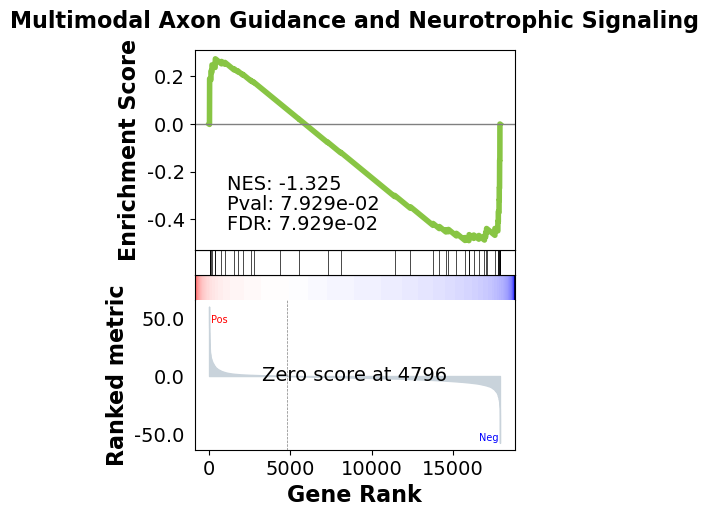

/tmp/ipykernel_4071734/1954738280.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
2025-11-14 19:25:44,874 [WARNING] Duplicated values found in preranked stats: 5.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:25:44,874 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:25:44,876 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:25:44,877 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 19:25:44,877 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 19:25:45,423 [INFO] Congratulations. GSEApy runs successfully................



myCAF


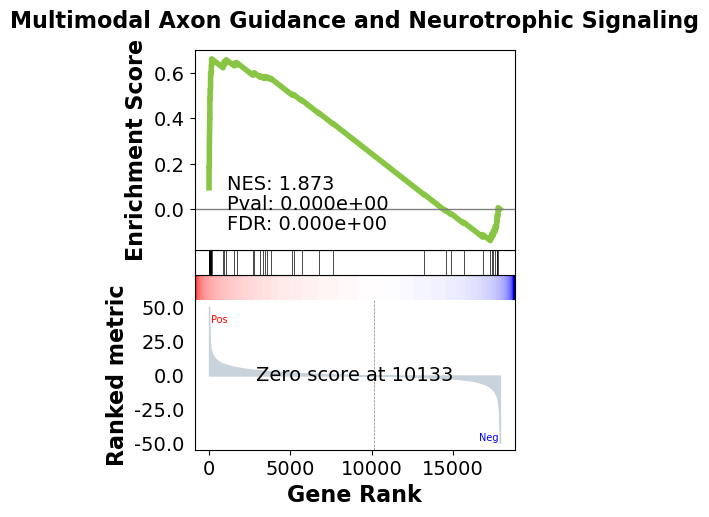

/tmp/ipykernel_4071734/1954738280.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
2025-11-14 19:25:45,919 [WARNING] Duplicated values found in preranked stats: 5.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:25:45,920 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:25:45,922 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:25:45,922 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 19:25:45,923 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 19:25:46,459 [INFO] Congratulations. GSEApy runs successfully................



apCAF


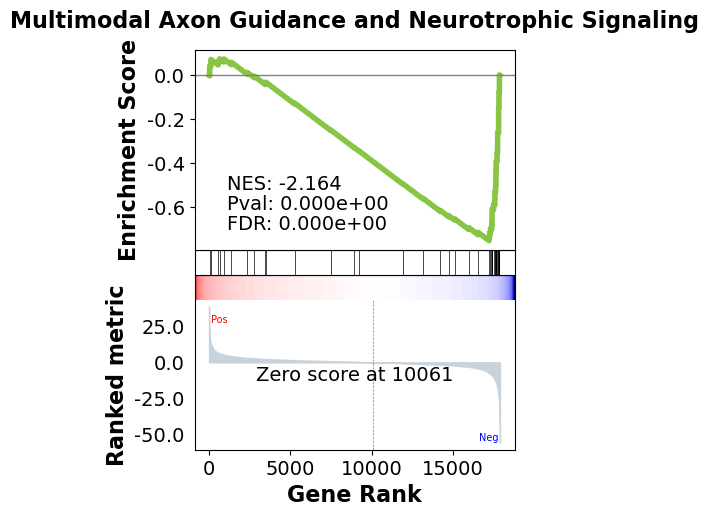

/tmp/ipykernel_4071734/1954738280.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
2025-11-14 19:25:47,249 [WARNING] Duplicated values found in preranked stats: 5.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 19:25:47,250 [INFO] Parsing data files for GSEA.............................
2025-11-14 19:25:47,252 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 19:25:47,252 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 19:25:47,253 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 19:25:47,796 [INFO] Congratulations. GSEApy runs successfully................



0


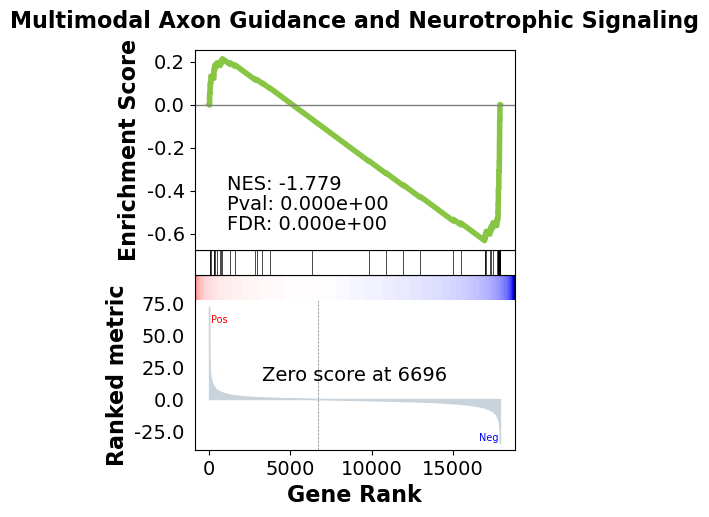

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
import re

k = -5   
for a in grouplist:
    k = k + 5
    sect = df.iloc[:,k:k+5]
    
    # Add ensemble gene info
    sect['ID'] = adata.var.id
    
    sect.sort_values(by=['score'], ascending=False, inplace=True)
    
    ranking = sect[['score']]
    ranking.reset_index(drop=False, inplace=True)
    ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
    
    pre_res = gp.prerank(
        rnk=ranking, 
        gene_sets=axon_pathways_gene_sets,
        threads=4,
        min_size=5,
        max_size=1000,
        permutation_num=1000,
        outdir=None,
        seed=6,
        verbose=True,
    )
    
    table = pre_res.res2d
    terms = pre_res.res2d.Term
    axs = pre_res.plot(terms=terms[0])
    
    fig = plt.gcf()
    fig.patch.set_alpha(0.0)

    # --- Bottom ranked metric panel ---
    axs = fig.axes 
    metric_ax = axs[0]  # axis with larger y-range, as you noted

    # --- Make axis background transparent ---
    metric_ax.set_facecolor('none')
    fig.patch.set_alpha(0.0)

    # --- Center the "Zero score at x genes" text ---
    # Loop over all text objects in the axis
    for txt in metric_ax.texts:
        # Usually the text contains "Zero score at"
        if "Zero score at" in txt.get_text():
            # Get current y-position
            y = txt.get_position()[1]
            # Center text horizontally
            txt.set_x(0.5)  # normalized coordinate
            txt.set_horizontalalignment('center')
            txt.set_verticalalignment('center')
            txt.set_transform(metric_ax.transAxes)  # use axis-relative coords
    
    print(a)

    plt.show()
    out_file = f"{OutDir}{a}_KPC_enrichment_plot_11-14-25.png"
    fig.savefig(out_file, dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    